In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#/content/drive/MyDrive/Thesis/figures/
# /content/drive/MyDrive/Thesis/datasets/
# /content/drive/MyDrive/Thesis/pickles/

Mounted at /content/drive


In [ ]:
import random
import numpy as np
import torch


SEED = 68
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import Metadata

train_dataset = '/content/drive/MyDrive/Thesis/datasets/german_credit_train.csv'
df = pd.read_csv(train_dataset)

In [ ]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,relationship status
0,no checking account,24,critical account / other credits existing (not...,car (used),2346,... < 100 DM,4 <= ... < 7 years,4,male,none,...,35,none,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1,single
1,0 <= ... < 200 DM,48,delay in paying off in the past,others,7582,100 <= ... < 500 DM,unemployed,2,male,none,...,31,none,for free,1,management / self-employed / highly qualified ...,1,"yes, registered under customer's name",yes,1,single
2,0 <= ... < 200 DM,12,existing credits paid back duly till now,radio/television,6468,unknown / no savings account,unemployed,2,male,none,...,52,none,own,1,management / self-employed / highly qualified ...,1,"yes, registered under customer's name",yes,2,single
3,0 <= ... < 200 DM,12,existing credits paid back duly till now,radio/television,766,500 <= ... < 1000 DM,1 <= ... < 4 years,4,male,none,...,66,none,own,1,unskilled - resident,1,none,yes,2,single
4,no checking account,6,no credits taken / all credits paid back duly,radio/television,426,... < 100 DM,... >= 7 years,4,male,none,...,39,none,own,1,unskilled - resident,1,none,yes,1,married/widowed


# Generating Metadata

In [ ]:
metadata = Metadata.detect_from_dataframe(
    data=df,
    table_name='german_credit')
print(metadata)

{
    "tables": {
        "german_credit": {
            "columns": {
                "checking_account_status": {
                    "sdtype": "categorical"
                },
                "duration_months": {
                    "sdtype": "numerical"
                },
                "credit_history": {
                    "sdtype": "categorical"
                },
                "purpose": {
                    "sdtype": "categorical"
                },
                "credit_amount": {
                    "sdtype": "numerical"
                },
                "savings_account": {
                    "sdtype": "categorical"
                },
                "employment_duration": {
                    "sdtype": "categorical"
                },
                "installment_rate": {
                    "sdtype": "categorical"
                },
                "sex": {
                    "sdtype": "categorical"
                },
                "other_debtors": {
         

In [ ]:
# update metadata that was not inferred properly
metadata.update_column('installment_rate', sdtype='numerical')
metadata.update_column('residence_duration', sdtype='numerical')
metadata.update_column('existing_credits', sdtype='numerical')
metadata.update_column('num_dependents', sdtype='numerical')

In [ ]:
print(metadata)

{
    "tables": {
        "german_credit": {
            "columns": {
                "checking_account_status": {
                    "sdtype": "categorical"
                },
                "duration_months": {
                    "sdtype": "numerical"
                },
                "credit_history": {
                    "sdtype": "categorical"
                },
                "purpose": {
                    "sdtype": "categorical"
                },
                "credit_amount": {
                    "sdtype": "numerical"
                },
                "savings_account": {
                    "sdtype": "categorical"
                },
                "employment_duration": {
                    "sdtype": "categorical"
                },
                "installment_rate": {
                    "sdtype": "numerical"
                },
                "sex": {
                    "sdtype": "categorical"
                },
                "other_debtors": {
           

In [ ]:
# metadata.save_to_json(filepath='/content/drive/MyDrive/Thesis/datasets/my_metadata_v1.json')

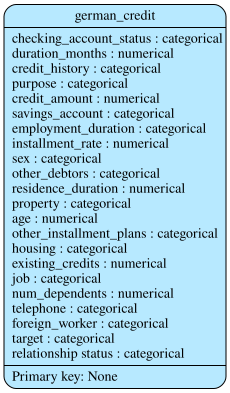

In [ ]:
metadata.visualize()

# Default CTGAN

In [ ]:
# Default CTGAN with no parameter changes
synthesizer = CTGANSynthesizer(metadata)
synthesizer.fit(df)

# synthetic_data = synthesizer.sample(num_rows=1000)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.head()
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data_default(epochs300).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_default.pkl')

In [ ]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 602.09it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 134.58it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [ ]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 618.31it/s]|
Column Shapes Score: 92.26%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:01<00:00, 143.50it/s]|
Column Pair Trends Score: 76.3%

Overall Score (Average): 84.28%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(default)')
fig.show()
# fig.write_image("/content/drive/MyDrive/Thesis/figures/loss_function_default.pdf") didn't work

In [ ]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()
# Epoch 300

# CTGAN configuration #1

The variables to be changed are: Epochs(default 300), Embedding Dimensions(default 128), Learning rate(default 2e-4), and if need be Batch size/discriminator steps

In [ ]:
# Epochs 100
synthesizer = CTGANSynthesizer(metadata, epochs=100)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs100).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=100.pkl')

In [ ]:
synthetic_data.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,relationship status
0,no checking account,14,existing credits paid back duly till now,radio/television,1138,... < 100 DM,1 <= ... < 4 years,3,female,none,...,26,bank,own,1,skilled employee / official,1,none,yes,1,divorced/separated
1,0 <= ... < 200 DM,11,existing credits paid back duly till now,car (new),495,unknown / no savings account,1 <= ... < 4 years,2,female,none,...,35,none,rent,2,skilled employee / official,1,"yes, registered under customer's name",yes,2,single
2,... < 0 DM,26,no credits taken / all credits paid back duly,radio/television,8376,... < 100 DM,... >= 7 years,1,male,none,...,34,none,own,1,skilled employee / official,1,none,yes,1,divorced/separated
3,... < 0 DM,30,critical account / other credits existing (not...,car (new),250,100 <= ... < 500 DM,1 <= ... < 4 years,4,female,none,...,42,none,own,1,management / self-employed / highly qualified ...,1,none,yes,2,divorced/separated
4,no checking account,4,existing credits paid back duly till now,radio/television,5750,... < 100 DM,4 <= ... < 7 years,1,female,none,...,34,none,own,1,skilled employee / official,1,none,yes,1,divorced/separated


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1228.87it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 79.24it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 423.76it/s]|
Column Shapes Score: 89.97%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:01<00:00, 196.53it/s]|
Column Pair Trends Score: 72.87%

Overall Score (Average): 81.42%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=100)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN configuration #2

In [ ]:
# Epochs 500
synthesizer = CTGANSynthesizer(metadata, epochs=500)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs500).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=500.pkl')

In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1427.85it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 276.14it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 579.55it/s]|
Column Shapes Score: 88.69%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 257.16it/s]|
Column Pair Trends Score: 72.63%

Overall Score (Average): 80.66%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=500)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN Configuration #3

In [ ]:
# Epochs 1000
synthesizer = CTGANSynthesizer(metadata, epochs=1000)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000.pkl')

In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1210.89it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 261.36it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 743.84it/s]|
Column Shapes Score: 88.36%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 260.80it/s]|
Column Pair Trends Score: 75.53%

Overall Score (Average): 81.94%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN config #4(Epochs=1000 from now)

Changing the embedding dimensions from now

In [ ]:
# embedding_dim = 256
synthesizer = CTGANSynthesizer(metadata, epochs=1000, embedding_dim=256, verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)

Gen. (-01.34) | Discrim. (-00.12): 100%|██████████| 1000/1000 [01:51<00:00,  8.98it/s]


OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000'

In [ ]:
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=256).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=256.pkl')

In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1021.01it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 163.11it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 652.75it/s]|
Column Shapes Score: 90.92%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 239.58it/s]|
Column Pair Trends Score: 73.62%

Overall Score (Average): 82.27%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000, embedding_dim=256)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN Config #5(option 1)
Trying this out just to see something(since according to sdv quality report 300 epochs was "optimal"


In [ ]:
synthesizer = CTGANSynthesizer(metadata, epochs=300, embedding_dim=256, verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs300+embedding_dim=256).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=300+embedding_dim=256.pkl')

Gen. (-00.74) | Discrim. (+00.19): 100%|██████████| 300/300 [00:38<00:00,  7.72it/s]


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1527.32it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 306.00it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 615.30it/s]|
Column Shapes Score: 90.35%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 245.42it/s]|
Column Pair Trends Score: 72.18%

Overall Score (Average): 81.26%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=300, embedding_dim=256)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN config #5(option #2)

Back to 1000 epochs

In [ ]:
# embedding_dim = 512
synthesizer = CTGANSynthesizer(metadata, epochs=1000, embedding_dim=512, verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512.pkl')

Gen. (-02.25) | Discrim. (-00.07): 100%|██████████| 1000/1000 [02:23<00:00,  6.95it/s]


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 802.95it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 147.68it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 697.53it/s]|
Column Shapes Score: 89.54%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 247.89it/s]|
Column Pair Trends Score: 74.73%

Overall Score (Average): 82.13%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000, embedding_dim=512)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN configuration #6

Now epochs=1000 and embedding_dim=512 fixed and move to learning rate. Learning rate will be changed for generator and discriminator simultaneously.

In [ ]:
# 2e-6 LR for both
synthesizer = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,generator_lr=2e-6,discriminator_lr=2e-6,verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=2e-6).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=2e-6.pkl')

Gen. (+01.04) | Discrim. (-00.24): 100%|██████████| 1000/1000 [02:23<00:00,  6.97it/s]


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1065.59it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 185.76it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 513.46it/s]|
Column Shapes Score: 77.9%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:01<00:00, 205.21it/s]|
Column Pair Trends Score: 65.05%

Overall Score (Average): 71.48%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000, embedding_dim=512, lr=2e-6)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN config #7

In [ ]:
# 2e-3 LR for both
synthesizer = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,generator_lr=2e-3,discriminator_lr=2e-3,verbose=True)
synthesizer.fit(df)
synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=2e-3).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=2e-3.pkl')

Gen. (+01.07) | Discrim. (-01.16): 100%|██████████| 1000/1000 [02:25<00:00,  6.85it/s]


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1256.60it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 319.47it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 632.59it/s]|
Column Shapes Score: 88.03%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 254.99it/s]|
Column Pair Trends Score: 71.2%

Overall Score (Average): 79.61%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000, embedding_dim=512, lr=2e-3)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN config #8

In [ ]:
# 1e-4 LR for both
synthesizer = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,generator_lr=1e-4,discriminator_lr=1e-4,verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-4).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=1e-4.pkl')

Gen. (-00.63) | Discrim. (-00.20): 100%|██████████| 1000/1000 [02:36<00:00,  6.40it/s]


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1286.60it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 214.14it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 790.85it/s]|
Column Shapes Score: 93.72%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 247.91it/s]|
Column Pair Trends Score: 76.52%

Overall Score (Average): 85.12%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000, embedding_dim=512, lr=1e-4)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

# CTGAN config #9

In [ ]:
# 1e-6 LR for both
synthesizer = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,generator_lr=1e-6,discriminator_lr=1e-6,verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-6).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=1e-6.pkl')

Gen. (+01.40) | Discrim. (-00.13): 100%|██████████| 1000/1000 [02:30<00:00,  6.65it/s]


In [ ]:
diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1468.27it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 273.05it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 434.30it/s]|
Column Shapes Score: 72.17%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:01<00:00, 217.69it/s]|
Column Pair Trends Score: 61.7%

Overall Score (Average): 66.93%



In [ ]:
fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(epochs=1000, embedding_dim=512, lr=1e-6)')
fig.show()

In [ ]:
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

In [ ]:
# side test tried it in another notebook and have the pickle file+data for it
# synthesizer = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,batch_size=120,discriminator_steps=5,generator_lr=1e-6,discriminator_lr=1e-6,verbose=True)
# synthesizer.fit(df)

# synthetic_data = synthesizer.sample(num_rows=1000)
# synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-6+side).csv', index=False)
# synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=1e-6+side.pkl')
# diagnostic = run_diagnostic(
#     real_data=df,
#     synthetic_data=synthetic_data,
#     metadata=metadata
# )
# quality_report = evaluate_quality(
#     df,
#     synthetic_data,
#     metadata
# )